# Finding non-principal branches of the QRE correspondence

Gambit computes logit quantal response equilibria (LQRE) ([McKPal95](https://gambitproject.readthedocs.io/en/latest/biblio.html#general-game-theory-articles-and-texts)) by path-following:
`logit_solve` and `logit_solve_branch` trace the branch of the LQRE correspondence which starts at the centroid at $\lambda = 0$, called the *principal branch*.
In many games the correspondence also has other branches.
These are not connected to the principal branch, so they cannot be reached by any method which follows the correspondence from the centroid.

[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) proposes a simulation-based method which in principle can locate points near *any* branch:
sample strategy profiles from a probability density constructed to concentrate near the graph of the correspondence.
A sampled point close to a branch can then be polished to high accuracy using Newton's method, and the branch containing it can be traced out from there.

This notebook illustrates the method on a small example, using Gambit for the game representation and the expected payoff calculations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

import pygambit as gbt

## A game whose correspondence has a second branch

We use a symmetric $2\times 2$ stag hunt.
Hunting stag pays 3 if the other player also hunts stag, and 0 otherwise; hunting hare pays 2 regardless of what the other player does.
The game has three Nash equilibria: (Stag, Stag), (Hare, Hare), and a symmetric mixed equilibrium in which each player hunts stag with probability $\frac{2}{3}$.

In [2]:
g = gbt.Game.from_arrays(
    [[3, 0], [2, 2]],
    [[3, 2], [0, 2]],
    title="Stag hunt",
)
for player in g.players:
    stag, hare = player.strategies
    stag.label = "Stag"
    hare.label = "Hare"
gbt.nash.enummixed_solve(g).equilibria

[[[Rational(1, 1), Rational(0, 1)], [Rational(1, 1), Rational(0, 1)]],
 [[Rational(2, 3), Rational(1, 3)], [Rational(2, 3), Rational(1, 3)]],
 [[Rational(0, 1), Rational(1, 1)], [Rational(0, 1), Rational(1, 1)]]]

The principal branch starts from uniform play at $\lambda = 0$.
Following it with `logit_solve_branch`, we see that as $\lambda$ grows it converges to (Hare, Hare) — the risk-dominant equilibrium.
The other two equilibria are invisible to this computation.

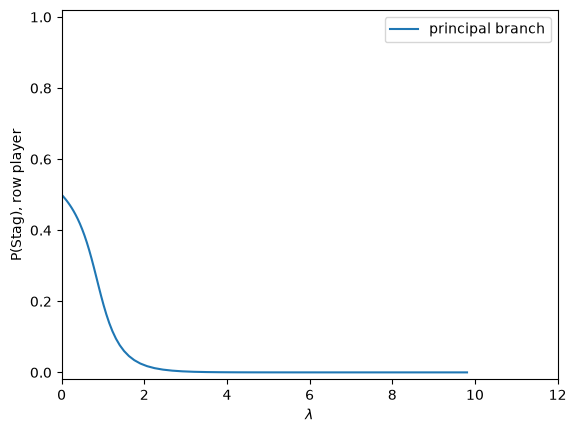

In [3]:
row, col = g.players
row_stag = row.strategies["Stag"]
principal = np.array([[q.lam, q.profile[row_stag]] for q in gbt.qre.logit_solve_branch(g)])

fig, ax = plt.subplots()
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

## A density which concentrates on the correspondence

A pair $(\sigma, \lambda)$ is a LQRE if for every player $i$

$$\sigma_i = \operatorname{softmax}(\lambda\, v_i(\sigma)),$$

where $v_i(\sigma)$ is the vector of expected payoffs to player $i$'s pure strategies when the others play according to $\sigma$.
[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) measures how far a profile is from satisfying these conditions with the penalty

$$\operatorname{obj}(\sigma, \lambda) \;=\; -\sum_i \bigl\lVert \sigma_i - \operatorname{softmax}(\lambda\, v_i(\sigma)) \bigr\rVert^2,$$

which is zero exactly on the correspondence and negative elsewhere.
Rather than treating $\lambda$ as a free parameter, it can be *eliminated* ([Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria), Section 3): given $\sigma$, the logit conditions are linear in $\lambda$ on the log-odds scale, so the least-squares fit has the closed form

$$\lambda^*(\sigma) = \max\left(0,\; \frac{\sum_i \sum_a x_{ia} y_{ia}}{\sum_i \sum_a x_{ia}^2}\right),$$

where $x_{ia}$ and $y_{ia}$ are the differences in expected payoff and in log probability between strategy $a$ and a fixed reference strategy of the same player.
We follow the author's implementation in the [online appendix](https://github.com/JamesBlandEcon/ApproxQRE) of [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).
Gambit's `strategy_value` provides the expected payoffs.

In [4]:
def softmax(x):
    """Map a vector of logits to a probability distribution, stably."""
    z = np.exp(x - np.max(x))
    return z / z.sum()


def strategy_values(game, probs):
    """Expected payoff to each pure strategy against the mixed profile `probs`.

    Returns one array per player, ordered as in `game.players`.
    """
    profile = game.mixed_strategy_profile([[float(p) for p in pr] for pr in probs])
    return [
        np.array([profile.strategy_value(s) for s in player.strategies])
        for player in game.players
    ]


def lambda_star(probs, values):
    """Closed-form least-squares lambda for a profile, from the logit conditions."""
    num = den = 0.0
    for pr, v in zip(probs, values, strict=True):
        y = np.log(pr[:-1]) - np.log(pr[-1])
        x = v[:-1] - v[-1]
        num += x @ y
        den += x @ x
    if den < 1e-12:  # all strategies payoff-equivalent: any lambda fits equally well
        return 0.0
    return max(num / den, 0.0)


def obj_fun(game, probs):
    """Bland's penalty objective; returns (obj, lambda*)."""
    values = strategy_values(game, probs)
    lam = lambda_star(probs, values)
    obj = -sum(np.sum((pr - softmax(lam * v)) ** 2) for pr, v in zip(probs, values, strict=True))
    return obj, lam

## Sampling near the correspondence

Draws from a density proportional to $\exp(w \cdot \operatorname{obj}(\sigma))$ concentrate near the set where $\operatorname{obj} = 0$, with the weight $w$ controlling how tightly.
[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) samples such densities using Hamiltonian Monte Carlo (Stan); a random-walk Metropolis sampler keeps this notebook self-contained.
Each chain starts from an independent uniformly-drawn profile, so chains can land on branches which are not connected to the centroid.

(The proposal walks on unconstrained log-odds, which implies a slightly different base measure than the uniform-on-the-simplex prior used by [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).
This is immaterial here: the draws serve only as approximate locations on the correspondence, not as posterior samples.)

In [5]:
PENALTY_WEIGHT = 10_000.0  # w; the value used in the online appendix of [Bla24]
N_CHAINS = 12
N_ITER = 1_500
STEP_SIZE = 0.15  # std. dev. of proposal increments in log-odds space

rng = np.random.default_rng(20260722)
draws = []
for _ in range(N_CHAINS):
    z = [np.log(rng.dirichlet(np.ones(len(p.strategies)))) for p in g.players]
    probs = [softmax(zi) for zi in z]
    obj, lam = obj_fun(g, probs)
    for _ in range(N_ITER):
        z_prop = [zi + STEP_SIZE * rng.standard_normal(zi.shape) for zi in z]
        probs_prop = [softmax(zi) for zi in z_prop]
        obj_prop, lam_prop = obj_fun(g, probs_prop)
        if np.log(rng.uniform()) < PENALTY_WEIGHT * (obj_prop - obj):
            z, probs, obj, lam = z_prop, probs_prop, obj_prop, lam_prop
        draws.append([lam, probs[0][0], probs[1][0], obj])
draws = np.array(draws)
on_locus = draws[draws[:, 3] > -1e-4]
len(on_locus), len(draws)

(15790, 18000)

Plotting the draws next to the principal branch reveals a second branch.

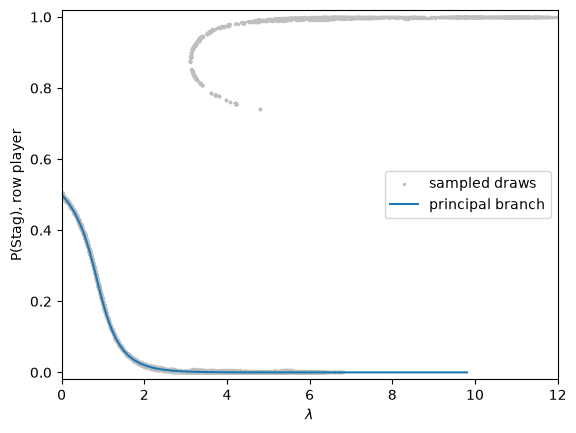

In [6]:
fig, ax = plt.subplots()
ax.scatter(on_locus[:, 0], on_locus[:, 1], s=2, color="0.75", label="sampled draws")
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

The second branch exists only above a minimum value of $\lambda$, where its two sides meet at a *fold*.
As $\lambda \to \infty$ the upper side converges to (Stag, Stag) and the lower side to the mixed equilibrium.

## Polishing a draw with Newton's method

A draw with $\operatorname{obj}$ near zero is only an approximate LQRE.
Fix $\lambda$ at the draw's $\lambda^*(\sigma)$; because probabilities on both sides of the fixed-point condition sum to one, dropping one component per player leaves a square nonlinear system, which `scipy.optimize.root` solves to machine precision in a few Newton-type iterations.

In [7]:
def pack(probs):
    """Per-player log-odds relative to the last strategy, concatenated."""
    return np.concatenate([np.log(pr[:-1]) - np.log(pr[-1]) for pr in probs])


def unpack(free, game):
    probs, k = [], 0
    for player in game.players:
        n = len(player.strategies)
        probs.append(softmax(np.concatenate([free[k:k + n - 1], [0.0]])))
        k += n - 1
    return probs


def qre_residual(free, game, lam):
    probs = unpack(free, game)
    values = strategy_values(game, probs)
    return np.concatenate(
        [(pr - softmax(lam * v))[:-1] for pr, v in zip(probs, values, strict=True)]
    )


def polish(game, probs, lam):
    """Newton-polish an approximate LQRE at fixed lambda; None if no convergence."""
    sol = scipy.optimize.root(qre_residual, pack(probs), args=(game, lam))
    return unpack(sol.x, game) if sol.success else None

Take the best draw on the upper side of the second branch and polish it.

In [8]:
principal_p = np.interp(on_locus[:, 0], principal[:, 0], principal[:, 1])
upper = on_locus[
    (np.abs(on_locus[:, 1] - principal_p) > 0.15)
    & (on_locus[:, 1] > 0.85)
    & (on_locus[:, 0] > 2) & (on_locus[:, 0] < 8)
]
lam_u, p_row, p_col, obj_u = upper[np.argmax(upper[:, 3])]
seed_upper = polish(g, [np.array([p_row, 1 - p_row]), np.array([p_col, 1 - p_col])], lam_u)
print(f"draw:     lambda* = {lam_u:.4f}, P(Stag) = {p_row:.4f}, obj = {obj_u:.2e}")
print(f"polished: P(Stag) = {seed_upper[0][0]:.6f}, "
      f"residual = {np.linalg.norm(qre_residual(pack(seed_upper), g, lam_u)):.2e}")

draw:     lambda* = 6.7779, P(Stag) = 0.9988, obj = -1.05e-12
polished: P(Stag) = 0.998835, residual = 0.00e+00


## Tracing the branch

From a polished point, the branch can be traced by stepping $\lambda$ in small increments, re-solving at each step from the previous solution.
This fixed-$\lambda$ continuation must stop at the fold, where the branch turns around in $\lambda$ and the Jacobian of the fixed-$\lambda$ system becomes singular.
(Gambit's own tracer avoids this by following the path by arclength instead — the approach described in [Tur05](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).)

In [9]:
LAMBDA_STEP = 0.05
LAMBDA_MAX = 12.0


def trace_branch(game, probs, lam):
    """Follow a branch through (probs, lam) in both directions of lambda."""
    points = [(lam, probs[0][0])]
    for direction in (+1.0, -1.0):
        cur_probs, cur_lam = probs, lam
        while 0.0 < cur_lam + direction * LAMBDA_STEP < LAMBDA_MAX:
            nxt = polish(game, cur_probs, cur_lam + direction * LAMBDA_STEP)
            if nxt is None:
                break  # no nearby solution: we have hit a fold
            cur_lam += direction * LAMBDA_STEP
            cur_probs = nxt
            points.append((cur_lam, cur_probs[0][0]))
    return np.array(sorted(points))


branch_upper = trace_branch(g, seed_upper, lam_u)
print(f"upper side: traced lambda in [{branch_upper[:, 0].min():.2f}, "
      f"{branch_upper[:, 0].max():.2f}], "
      f"P(Stag) at lambda_max = {branch_upper[-1, 1]:.4f}")

upper side: traced lambda in [3.13, 11.98], P(Stag) at lambda_max = 1.0000


The same procedure applied to a draw on the lower side traces the other half of the branch, which approaches the fold from below.

In [10]:
lower = on_locus[
    (on_locus[:, 1] > 0.4) & (on_locus[:, 1] < 0.85) & (on_locus[:, 0] > 4)
]
lam_l, p_row, p_col, _ = lower[np.argmax(lower[:, 3])]
seed_lower = polish(g, [np.array([p_row, 1 - p_row]), np.array([p_col, 1 - p_col])], lam_l)
branch_lower = trace_branch(g, seed_lower, lam_l)
print(f"lower side: traced lambda in [{branch_lower[:, 0].min():.2f}, "
      f"{branch_lower[:, 0].max():.2f}], "
      f"P(Stag) at lambda_max = {branch_lower[-1, 1]:.4f}")

lower side: traced lambda in [3.14, 11.99], P(Stag) at lambda_max = 0.6887


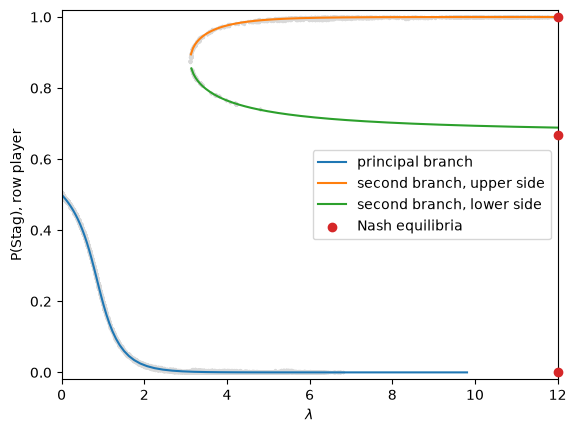

In [11]:
fig, ax = plt.subplots()
ax.scatter(on_locus[:, 0], on_locus[:, 1], s=2, color="0.85")
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.plot(branch_upper[:, 0], branch_upper[:, 1], color="C1", label="second branch, upper side")
ax.plot(branch_lower[:, 0], branch_lower[:, 1], color="C2", label="second branch, lower side")
ax.scatter([12, 12, 12], [0, 2 / 3, 1], marker="o", color="C3", zorder=5,
           clip_on=False, label="Nash equilibria")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="center right")
plt.show()

## Remarks

The upper side of the second branch converges to the payoff-dominant equilibrium (Stag, Stag), and the lower side to the mixed equilibrium — neither of which can be found by following the correspondence from the centroid.
The two sides stop just short of each other at the fold, which fixed-$\lambda$ continuation cannot go around.

Some natural directions from here:

- Gambit's internal path-follower could trace the whole branch (including around the fold) starting from any polished point; the C++ implementation accepts arbitrary starting points, although this is not currently exposed in the Python API.
- The sampling method needs only expected payoffs, which Gambit computes for any finite game, so the same code applies well beyond $2\times 2$ examples; [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) discusses performance in larger games.
- [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) builds a Bayesian estimation procedure on top of this sampling approach, in which the penalty acts as an equilibrium constraint inside a posterior sampler; see also [BlaTur23](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) on maximum-likelihood estimation along the principal branch with `logit_estimate`.